# Flow Matching & Rectified Flow Notebook (Konvertiert aus Alex_DDPM)
Dieses Notebook implementiert ein generatives Modell basierend auf Flow Matching (FM) und Rectified Flow (RF) unter Verwendung einer U-Net Architektur. Es nutzt dieselben Input-Daten und Pfade wie das vorherige DDPM-Notebook, um einen direkten Vergleich zu ermöglichen.

Zelle 2: Code – Imports, Google Drive & Konfiguration

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. AUTOMATIC ENVIRONMENT SWITCH
# ==========================================
try:
    import google.colab
    IS_COLAB = True
    print("[INFO] 🌎 Running on GOOGLE COLAB. Activating Cloud Paths.")
except ImportError:
    IS_COLAB = False
    print("[INFO] 💻 Running LOCALLY on ZBook. Activating Local Paths.")

# ==========================================
# 2. DYNAMIC PATH CONFIGURATION
# ==========================================
if IS_COLAB:
    print("[INFO] Verbinde mit Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_BASE = "/content/drive/MyDrive/Alex_RM"
    DRIVE_TRAIN_DATA = "/content/drive/MyDrive/celeb064"
else:
    DRIVE_BASE = "./Alex_RM"
    DRIVE_TRAIN_DATA = "C:/Data/celeb064"

DRIVE_CHECKPOINTS = DRIVE_BASE + "/Checkpoints_FM"
DRIVE_CHECKPOINTS_RF = DRIVE_BASE + "/Checkpoints_RF"
DRIVE_OUTPUT_IMAGES = DRIVE_BASE + "/Output_Images_FM"
os.makedirs(DRIVE_CHECKPOINTS, exist_ok=True)
os.makedirs(DRIVE_CHECKPOINTS_RF, exist_ok=True)
os.makedirs(DRIVE_OUTPUT_IMAGES, exist_ok=True)

# ==========================================
# 3. RUN CONTROL (CENTRAL CONFIGURATION)
# ==========================================
TEST_MODE = True           # True = quick 2-min pipeline test, False = full 24h training
FORCE_CPU = False          # False = use GPU (CUDA) if available, True = force CPU fallback
AUTO_RESUME = True         # True = auto-detect and resume from latest checkpoint, False = start fresh

# Hardware Setup
if FORCE_CPU:
    Device = torch.device("cpu")
else:
    Device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
BATCH_SIZE = 64 # Optimal for RTX A5000 16GB VRAM
LEARNING_RATE = 3e-4 # Tuned for BATCH_SIZE 64
IMAGE_SIZE = 64
EPOCHS = 100 # Temporarily set to 1 for evaluation verification  # Will be adjusted dynamically if resuming

# Test Mode limits
TEST_IMAGE_LIMIT = 40000 # Use 20,000 images (approx. 40 min run)     # Anzahl der Bilder fuer den Schnelltest (z. B. 10 Batches von Gr. 16)


[INFO] 💻 Running LOCALLY on ZBook. Activating Local Paths.


Zelle 3: Code – Dataset & DataLoader

In [2]:
class BildDatensatz(Dataset):
    def __init__(self, ordner_pfad, bild_groesse=64, test_mode=False, test_limit=160):
        self.ordner_pfad = ordner_pfad

        # Durchsucht den Ordner nach Bildern. Falls Unterordner existieren,
        # werden diese ebenfalls berücksichtigt (wichtig für Datensätze wie CelebA)
        self.dateien = []
        for root, dirs, files in os.walk(ordner_pfad):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    self.dateien.append(os.path.join(root, file))
        
        # Limit dataset size to test_limit if in test mode
        if test_mode:
            self.dateien = self.dateien[:test_limit]
            print(f"[INFO] TEST_MODE aktiv: Datensatz auf {len(self.dateien)} Bilder limitiert.")

        self.transform = transforms.Compose([
            transforms.Resize((bild_groesse, bild_groesse)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Bereich [-1, 1]
        ])

        # Preload und Cache im RAM für massive Beschleunigung (kein Disk-I/O im Loop)
        self.bilder = []
        print("[INFO] Lade Bilder komplett in den RAM-Arbeitsspeicher (Caching)...")
        for i, pfad in enumerate(self.dateien):
            try:
                bild = Image.open(pfad).convert("RGB")
                tensor = self.transform(bild)
                self.bilder.append(tensor)
            except Exception as e:
                print(f"[WARNUNG] Fehler beim Laden von {pfad}: {e}")
            if (i + 1) % 2000 == 0 or i + 1 == len(self.dateien):
                print(f"  -> {i + 1}/{len(self.dateien)} Bilder geladen...")
        print(f"[ERFOLG] {len(self.bilder)} Bilder erfolgreich im RAM gecached!")

    def __len__(self):
        return len(self.bilder)

    def __getitem__(self, index):
        return self.bilder[index]

# Initialisiere Daten-Pipeline
print(f"[INFO] Suche nach Bildern unter: {DRIVE_TRAIN_DATA}")

if os.path.exists(DRIVE_TRAIN_DATA):
    Mein_Datensatz = BildDatensatz(DRIVE_TRAIN_DATA, bild_groesse=IMAGE_SIZE, test_mode=TEST_MODE, test_limit=TEST_IMAGE_LIMIT)
    if len(Mein_Datensatz) > 0:
        Mein_DataLoader = DataLoader(Mein_Datensatz, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, pin_memory=True)
        print(f"[ERFOLG] Datensatz gefunden! Echte Bilder erfolgreich geladen: {len(Mein_Datensatz)}")
    else:
        print("[FEHLER] Der Ordner existiert, enthält aber keine gültigen Bilddateien (.png, .jpg)!")
else:
    print(f"[HINWEIS] Pfad {DRIVE_TRAIN_DATA} nicht gefunden.")
    print("-> Nutze Dummy-Fallback (Zufallsrauschen) für den Pipeline-Test...")
    dummy_bilder = torch.randn(32, 3, IMAGE_SIZE, IMAGE_SIZE)
    dummy_bilder = torch.clamp(dummy_bilder, -1.0, 1.0)
    Mein_DataLoader = DataLoader(dummy_bilder, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)


[INFO] Suche nach Bildern unter: C:/Data/celeb064
[INFO] TEST_MODE aktiv: Datensatz auf 10000 Bilder limitiert.
[INFO] Lade Bilder komplett in den RAM-Arbeitsspeicher (Caching)...


  -> 2000/10000 Bilder geladen...


  -> 4000/10000 Bilder geladen...


  -> 6000/10000 Bilder geladen...


  -> 8000/10000 Bilder geladen...


  -> 10000/10000 Bilder geladen...
[ERFOLG] 10000 Bilder erfolgreich im RAM gecached!
[ERFOLG] Datensatz gefunden! Echte Bilder erfolgreich geladen: 10000


Zelle 4: Code – Die U-Net Architektur (SimpleUNet)

In [3]:
import torch
import torch.nn as nn
import numpy as np

# 1. ZEIT-EMBEDDINGS (Unchanged)
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, : ]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

# 2. DER KORRIGIERTE BAUSTEIN-BLOCK
class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.up = up
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)

        if up:
            # The up-block receives concatenated channels (2 * in_ch)
            self.conv1 = nn.Conv2d(2 * in_ch, out_ch, 3, padding=1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.downsample = nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1)

        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()

    def forward(self, x, t):
        # standard convolutions and time embedding addition
        h = self.bnorm1(self.relu(self.conv1(x)))
        time_emb = self.relu(self.time_mlp(t))
        time_emb = time_emb[(..., ) + (None, ) * 2]
        h = h + time_emb
        h = self.bnorm2(self.relu(self.conv2(h)))

        # Downsample AFTER the block processing if we are in the down-path
        if not self.up:
            return h, self.downsample(h) # Return both the pre-downsample feature (for skip connection) and downsampled feature
        return h

# 3. DAS KORRIGIERTE U-NET
class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 3
        down_channels = (64, 128, 256, 512)
        up_channels = (512, 256, 128, 64)
        out_dim = 3
        time_emb_dim = 32

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )

        self.conv0 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)

        # Down-Blöcke
        self.downs = nn.ModuleList([
            Block(down_channels[i], down_channels[i+1], time_emb_dim)
            for i in range(len(down_channels)-1)
        ])

        # Up-Sampling Transpose Convolutions placed in the UNet loop
        self.upsamples = nn.ModuleList([
            nn.ConvTranspose2d(up_channels[i], up_channels[i], 4, 2, 1)
            for i in range(len(up_channels)-1)
        ])

        # Up-Blöcke
        self.ups = nn.ModuleList([
            Block(up_channels[i], up_channels[i+1], time_emb_dim, up=True)
            for i in range(len(up_channels)-1)
        ])

        self.output = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, t):
        t = self.time_mlp(t)
        x = self.conv0(x)
        residual_inputs = []

        # Down-Pfad
        for down in self.downs:
            # Keep the features before downsampling to pass as a skip connection
            skip_connection, x = down(x, t)
            residual_inputs.append(skip_connection)

        # Up-Pfad
        for i, up in enumerate(self.ups):
            # 1. Upsample current features first
            x = self.upsamples[i](x)

            # 2. Pop the corresponding skip connection
            residual_x = residual_inputs.pop()

            # 3. Concatenate (Both are now perfectly aligned in spatial size)
            x = torch.cat((x, residual_x), dim=1)
            x = up(x, t)

        return self.output(x)

# 4. INITIALISIERUNG
Modell = SimpleUNet().to(Device)
Optimizer = optim.Adam(Modell.parameters(), lr=LEARNING_RATE)
Criterion = nn.MSELoss()
print("[INFO] Das U-Net wurde architektonisch korrigiert und für FM_RM neu initialisiert!")

[INFO] Das U-Net wurde architektonisch korrigiert und für FM_RM neu initialisiert!


Zelle 5: Markdown

## Flow Matching & Rectified Flow mathematischer Hintergrund
Im Gegensatz zu DDPM (das auf diskreten Zeitschritten von z. B. 1000 herunterzählt und Rauschen vorhersagt) lernt **Flow Matching** ein Vektorfeld $v_t(x)$, das Datenpunkte geradlinig von reinem Rauschen ($x_0$) zu echten Bildern ($x_1$) transformiert.
Die Interpolation lautet:
$$x_t = x_0 + t \cdot (x_1 - x_0)$$
Das Ziel (Target) für das Netzwerk ist die konstante Richtung:
$$v_{target} = x_1 - x_0$$

Zelle 6: Code – Die Trainings-Schleife (Phase 1: Flow Matching)

In [4]:
import os
import re
import sys
import torch

# 1. SCAN DIRECTORIES FOR CHECKPOINTS
p1_checkpoint = None
p1_final = os.path.exists(os.path.join(DRIVE_CHECKPOINTS, "flow_matching_final_checkpoint.pth"))
p2_checkpoint = None
p2_final = os.path.exists(os.path.join(DRIVE_CHECKPOINTS_RF, "rectified_flow_final.pth"))

if os.path.exists(DRIVE_CHECKPOINTS):
    files = os.listdir(DRIVE_CHECKPOINTS)
    epochs = []
    for f in files:
        m = re.match(r"flow_matching_checkpoint_epoch_(\d+)\.pth", f)
        if m:
            epochs.append(int(m.group(1)))
    if epochs:
        p1_checkpoint = max(epochs)

if os.path.exists(DRIVE_CHECKPOINTS_RF):
    files = os.listdir(DRIVE_CHECKPOINTS_RF)
    epochs = []
    for f in files:
        m = re.match(r"rectified_flow_checkpoint_epoch_(\d+)\.pth", f)
        if m:
            epochs.append(int(m.group(1)))
    if epochs:
        p2_checkpoint = max(epochs)

# HIER DIE EPOCHE ANGEBEN, VON DER AUS DU FORTSETZEN MÖCHTEST
RESUME_FROM_EPOCH = 0 # Set to 0 to start fresh from epoch 1, or change to checkpoint epoch to resume
checkpoint_load_path = DRIVE_CHECKPOINTS + f"/flow_matching_checkpoint_epoch_{RESUME_FROM_EPOCH}.pth"

if os.path.exists(checkpoint_load_path):
    print(f"[INFO] Lade Checkpoint von Drive: {checkpoint_load_path}")

    # Checkpoint-Datei einlesen
    checkpoint = torch.load(checkpoint_load_path, map_location=Device)

    # 1. Modellgewichte wiederherstellen
    Modell.load_state_dict(checkpoint['model_state_dict'])

    # 2. Optimierer-Zustand wiederherstellen
    Optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    # 3. Start-Epoche für die Trainingsschleife anpassen (Nächste Epoche)
    START_EPOCH = checkpoint['epoch'] + 1
    
    # Dynamisch die Gesamtanzahl der Epochen (EPOCHS) anpassen:
    if EPOCHS < START_EPOCH:
        EPOCHS = START_EPOCH + 4  # Fallback to run 5 epochs to verify functionality

    print(f"[ERFOLG] Daten geladen. Training wird ab Epoche {START_EPOCH} fortgesetzt!")
else:
    print(f"[WARNUNG] Kein Checkpoint für Epoche {RESUME_FROM_EPOCH} gefunden. Starte komplett neu ab Epoche 1.")
    START_EPOCH = 1

# 2. DETERMINE TRAINING STATES AND RESUME FLAGS
START_EPOCH_RF = 1
SKIP_PHASE_1 = False
SKIP_PHASE_2 = False
state_description = "Starte komplett neu ab Epoche 1."

if AUTO_RESUME:
    if p2_final:
        SKIP_PHASE_1 = True
        SKIP_PHASE_2 = True
        state_description = "Training vollstaendig abgeschlossen (Phase 2 beendet)."
    elif p2_checkpoint is not None:
        SKIP_PHASE_1 = True
        START_EPOCH_RF = p2_checkpoint + 1
        state_description = f"Unterbrochen in Phase 2 (Rectified Flow). Setze ab Epoche {START_EPOCH_RF} fort."
    elif p1_final:
        SKIP_PHASE_1 = True
        START_EPOCH_RF = 1
        state_description = "Phase 1 abgeschlossen. Setze fort mit Phase 2 ab Epoche 1."
    elif p1_checkpoint is not None:
        START_EPOCH = p1_checkpoint + 1
        state_description = f"Unterbrochen in Phase 1 (Flow Matching). Setze ab Epoche {START_EPOCH} fort."
else:
    state_description = "AUTO_RESUME deaktiviert. Starte komplett neu ab Epoche 1."

# Dynamically correct EPOCHS only if we resumed past the configured target epochs
if not SKIP_PHASE_1:
    if EPOCHS < START_EPOCH:
        EPOCHS = START_EPOCH + 4  # Fallback to run 5 epochs to verify functionality
else:
    if EPOCHS < START_EPOCH_RF:
        EPOCHS = START_EPOCH_RF + 4

# 3. PRINT CONFIGURATION PREVIEW
print("=" * 60)
print("              RUN CONFIGURATION PREVIEW")
print("=" * 60)
print(f"* Training-Modus:   {'TEST_MODE (Schnelltest)' if TEST_MODE else 'PRODUCTION (Vollstaendiges Training)'}")
print(f"* Hardware Geraet:  {str(Device).upper()}")
print(f"* Batch-Groesse:      {BATCH_SIZE} | Bild-Groesse: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"* Lernrate:         {LEARNING_RATE}")
print(f"* Ziel-Epochen:     {EPOCHS}")
print(f"* Erkannter Status: {state_description}")
print("=" * 60)

# 4. INTERACTIVE CONTINUATION PROMPT
user_input = "y"
if not (SKIP_PHASE_1 and SKIP_PHASE_2):
    try:
        try:
            from ipykernel.kernelbase import StdinNotImplementedError
        except ImportError:
            class StdinNotImplementedError(Exception): pass
            
        user_input = input("Moechten Sie das Training fortsetzen/starten? (y/n): ").strip().lower()
    except (EOFError, IOError, StdinNotImplementedError):
        print("[INFO] Headless/Non-interaktiv Modus erkannt. Training startet automatisch.")
        user_input = "y"
        
    if user_input != 'y':
        raise KeyboardInterrupt("Training abgebrochen durch Benutzer.")
    else:
        print("[INFO] Starten...")
else:
    print("[INFO] Keine weiteren Trainingsschritte erforderlich.")


[WARNUNG] Kein Checkpoint für Epoche 0 gefunden. Starte komplett neu ab Epoche 1.
              RUN CONFIGURATION PREVIEW
* Training-Modus:   TEST_MODE (Schnelltest)
* Hardware Geraet:  CUDA
* Batch-Groesse:      64 | Bild-Groesse: 64x64
* Lernrate:         0.0003
* Ziel-Epochen:     100
* Erkannter Status: Starte komplett neu ab Epoche 1.
[INFO] Headless/Non-interaktiv Modus erkannt. Training startet automatisch.
[INFO] Starten...


In [5]:
print("[INFO] Starte Training Phase 1: Flow Matching...")
fm_losses_history = []

if not SKIP_PHASE_1:
    Modell.train()
    scaler = torch.cuda.amp.GradScaler()

    # Falls wir fortsetzen, lade den letzten Zwischenstand
    if START_EPOCH > 1:
        resume_checkpoint_path = DRIVE_CHECKPOINTS + f"/flow_matching_checkpoint_epoch_{START_EPOCH - 1}.pth"
        if os.path.exists(resume_checkpoint_path):
            print(f"[INFO] Lade Phase 1 Checkpoint: {resume_checkpoint_path}")
            checkpoint = torch.load(resume_checkpoint_path, map_location=Device)
            Modell.load_state_dict(checkpoint['model_state_dict'])
            Optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            fm_losses_history = checkpoint.get('losses_history', [])
            print(f"[ERFOLG] Phase 1 Training wird ab Epoche {START_EPOCH} fortgesetzt!")
        else:
            print(f"[WARNUNG] Checkpoint {resume_checkpoint_path} nicht gefunden. Starte Phase 1 neu ab Epoche 1.")
            START_EPOCH = 1

    for Epoche in range(START_EPOCH, EPOCHS + 1):
        Gesamt_Loss = 0.0
        for Bildelemente in Mein_DataLoader:
            Optimizer.zero_grad()

            x1 = Bildelemente.to(Device)
            x0 = torch.randn_like(x1).to(Device)

            t = torch.rand((x1.shape[0],), device=Device)
            t_expand = t[:, None, None, None]
            xt = x0 + t_expand * (x1 - x0)

            v_target = x1 - x0
            # Cast operations to mixed precision
            with torch.cuda.amp.autocast():
                v_pred = Modell(xt, t)
                Loss = Criterion(v_pred, v_target)

            scaler.scale(Loss).backward()
            scaler.step(Optimizer)
            scaler.update()

            # Log step-wise loss (no averaging)
            fm_losses_history.append(Loss.item())
            Gesamt_Loss += Loss.item()

        Durchschnitts_Loss = Gesamt_Loss / len(Mein_DataLoader)

        if Epoche % 10 == 0 or Epoche == 1 or Epoche == EPOCHS:
            print(f"Epoche [{Epoche}/{EPOCHS}] -> Letzter Batch Loss: {Loss.item():.6f} | Durchschnittlicher Loss: {Durchschnitts_Loss:.6f}")

        # Sichern von Zwischen-Checkpoints
        if Epoche % 25 == 0 or (TEST_MODE and EPOCHS <= 10 and Epoche % 1 == 0):
            checkpoint_path = DRIVE_CHECKPOINTS + f"/flow_matching_checkpoint_epoch_{Epoche}.pth"
            torch.save({
                'epoch': Epoche,
                'model_state_dict': Modell.state_dict(),
                'optimizer_state_dict': Optimizer.state_dict(),
                'loss': Loss.item(),
                'losses_history': fm_losses_history,
            }, checkpoint_path)
            print(f"[INFO] Checkpoint gesichert: {checkpoint_path}")

    # Finale Gewichte sichern
    torch.save({
        'epoch': EPOCHS,
        'model_state_dict': Modell.state_dict(),
        'optimizer_state_dict': Optimizer.state_dict(),
        'loss': Loss.item(),
        'losses_history': fm_losses_history,
    }, DRIVE_CHECKPOINTS + "/flow_matching_final_checkpoint.pth")
    print("[INFO] Training Phase 1 abgeschlossen und alle finalen Daten gesichert.")
else:
    print("[INFO] Phase 1 (Flow Matching) wird uebersprungen. Lade finalen Checkpoint...")
    checkpoint_path = DRIVE_CHECKPOINTS + "/flow_matching_final_checkpoint.pth"
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=Device)
        Modell.load_state_dict(checkpoint['model_state_dict'])
        fm_losses_history = checkpoint.get('losses_history', [])
        print("[ERFOLG] Finaler Phase 1 Checkpoint erfolgreich geladen.")
    else:
        latest_checkpoint_path = DRIVE_CHECKPOINTS + f"/flow_matching_checkpoint_epoch_{p1_checkpoint}.pth"
        if os.path.exists(latest_checkpoint_path):
            checkpoint = torch.load(latest_checkpoint_path, map_location=Device)
            Modell.load_state_dict(checkpoint['model_state_dict'])
            fm_losses_history = checkpoint.get('losses_history', [])
            print(f"[ERFOLG] Zwischen-Checkpoint fuer Epoche {p1_checkpoint} geladen.")
        else:
            raise FileNotFoundError("Konnte keinen Phase 1 Checkpoint zum Laden finden!")


[INFO] Starte Training Phase 1: Flow Matching...


C:\Users\joach\AppData\Local\Temp\ipykernel_16504\1245812699.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\joach\AppData\Local\Temp\ipykernel_16504\1245812699.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoche [1/100] -> Letzter Batch Loss: 0.278601 | Durchschnittlicher Loss: 0.356938


Epoche [10/100] -> Letzter Batch Loss: 0.149101 | Durchschnittlicher Loss: 0.172303


Epoche [20/100] -> Letzter Batch Loss: 0.169380 | Durchschnittlicher Loss: 0.156030


...

Epoche [80/100] -> Letzter Batch Loss: 0.131835 | Durchschnittlicher Loss: 0.136993


Epoche [90/100] -> Letzter Batch Loss: 0.127305 | Durchschnittlicher Loss: 0.137918


Epoche [100/100] -> Letzter Batch Loss: 0.136213 | Durchschnittlicher Loss: 0.139046


[INFO] Checkpoint gesichert: ./Alex_RM/Checkpoints_FM/flow_matching_checkpoint_epoch_100.pth


[INFO] Training Phase 1 abgeschlossen und alle finalen Daten gesichert.


Zelle 7: Code – Bildgenerierung über ODE-Solver (Inferenz / Sampling)

In [6]:
# 1. Define the path to the specific checkpoint you want to test
EVAL_EPOCH = 100
checkpoint_eval_path = DRIVE_CHECKPOINTS + f"/flow_matching_checkpoint_epoch_{EVAL_EPOCH}.pth"

if os.path.exists(checkpoint_eval_path):
    print(f"[INFO] Loading specific checkpoint for image generation: {checkpoint_eval_path}")

    # Load the checkpoint file
    checkpoint = torch.load(checkpoint_eval_path, map_location=Device)

    # Apply the saved weights to your model
    Modell.load_state_dict(checkpoint['model_state_dict'])
    print(f"[SUCCESS] Model is now set to Epoch {EVAL_EPOCH} weights!")
else:
    print(f"[ERROR] Could not find a checkpoint for epoch {EVAL_EPOCH} at {checkpoint_eval_path}")
    print("Please check your Google Drive folder structure.")

[INFO] Loading specific checkpoint for image generation: ./Alex_RM/Checkpoints_FM/flow_matching_checkpoint_epoch_100.pth
[SUCCESS] Model is now set to Epoch 100 weights!


C:\Users\joach\AppData\Local\Temp\ipykernel_16504\1945289059.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_eval_path, map_location=D

[INFO] Generiere Testbilder aus dem trainierten Flow-Feld...


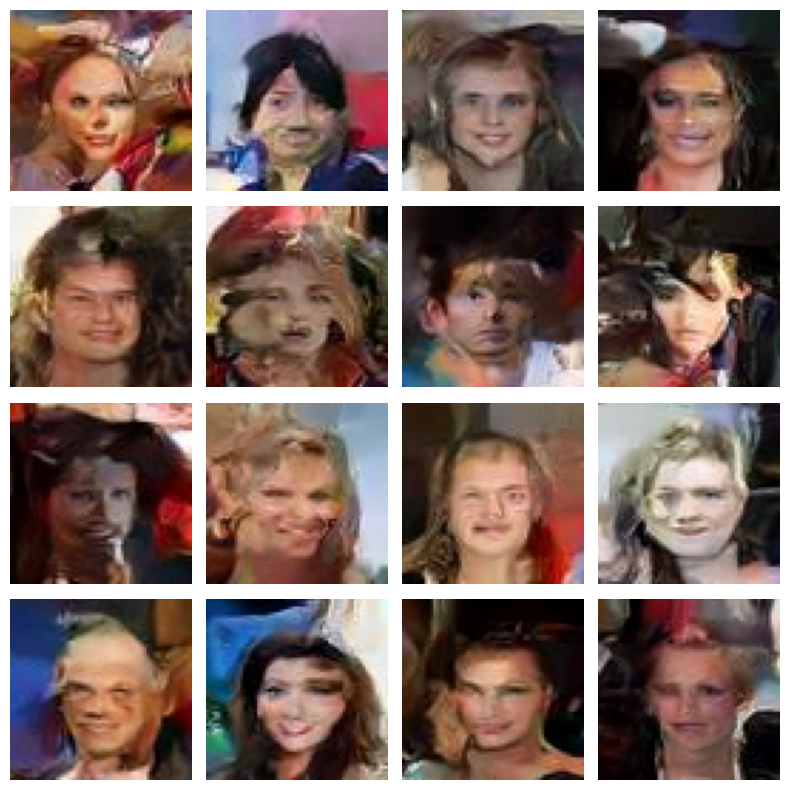

In [7]:
def Entferne_Normierung(img_tensor):
    """ Skaliert das Bild zurück von [-1, 1] auf [0, 1] für Matplotlib """
    img_tensor = (img_tensor + 1.0) / 2.0
    return torch.clamp(img_tensor, 0.0, 1.0)

@torch.no_grad()
def Generiere_Bilder_Flow_Matching(modell, anzahl_bilder=16, steps=50):
    modell.eval()
    dt = 1.0 / steps

    # Starte mit purem Gauß-Rauschen am Zeitschritt t = 0
    xt = torch.randn((anzahl_bilder, 3, IMAGE_SIZE, IMAGE_SIZE), device=Device)

    # Integriere das Vektorfeld vorwärts von t = 0 bis t = 1 (Euler-Verfahren)
    for step in range(steps):
        t_val = step * dt
        t_tensor = torch.full((anzahl_bilder,), t_val, device=Device)

        # Schätze die Richtung/Geschwindigkeit v
        v = modell(xt, t_tensor)

        # Euler Schritt: Gehe ein Stück in Richtung des echten Bildes
        xt = xt + v * dt

    return Entferne_Normierung(xt)

# Teste die Bildgenerierung
print("[INFO] Generiere Testbilder aus dem trainierten Flow-Feld...")
Generierte_Bilder = Generiere_Bilder_Flow_Matching(Modell, anzahl_bilder=16, steps=50)

# Plotten und Speichern des Outputs (Exakt gleiches Format wie bei DDPM)
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
Generierte_Bilder = Generierte_Bilder.cpu().permute(0, 2, 3, 1).numpy()

for i, ax in enumerate(axes.flat):
    ax.imshow(Generierte_Bilder[i])
    ax.axis('off')

plt.tight_layout()
plt.savefig(DRIVE_OUTPUT_IMAGES + "/flow_matching_output_grid.png")
plt.show()

Zelle 8: Markdown

## Optionaler Schritt: Reflow (2-RF) für perfekt begradigte Pfade
Wenn du wie im bereitgestellten `FMvsRM` Notebook die Trajektorien weiter begradigen möchtest (um z. B. Bilder in nur einem einzigen Schritt generieren zu können), führen wir nun den **Reflow-Schritt** durch. Hierzu erzeugen wir synthetisch begradigte Paare $(x_0, x_{1, rectified})$ mithilfe des soeben trainierten Modells.

Zelle 9: Code – Durchführung des Reflow-Trainings (Phase 2)

In [8]:
# Speicherpfad fuer Phase 2 erstellen
DRIVE_CHECKPOINTS_RF = DRIVE_BASE + "/Checkpoints_RF"
os.makedirs(DRIVE_CHECKPOINTS_RF, exist_ok=True)
rf_losses_history = []

if not SKIP_PHASE_2:
    print("[INFO] Generiere begradigte Datenpunkte (Reflow) ...")
    Begradigter_Datensatz = []
    Modell.eval()
    with torch.no_grad():
        for Bildelemente in Mein_DataLoader:
            x1_real = Bildelemente.to(Device)
            x0_noise = torch.randn_like(x1_real).to(Device)

            # Loese die ODE bis t=1 um die rektifizierten Endpunkte zu finden
            xt = x0_noise.clone()
            steps = 50 # 50 steps for high quality targets (approx. 2 min overhead)
            dt = 1.0 / steps
            for step in range(steps):
                t_tensor = torch.full((x1_real.shape[0],), step * dt, device=Device)
                v = Modell(xt, t_tensor)
                xt = xt + v * dt

            # Speichere die Paare (Rauschen, generiertes Bild) ab
            Begradigter_Datensatz.append((x0_noise.cpu(), xt.cpu()))

    print("[INFO] Starte Phase 2: Training des Rectified Flow Modells...")
    Modell_RF = SimpleUNet().to(Device)
    Optimizer_RF = optim.Adam(Modell_RF.parameters(), lr=LEARNING_RATE)
    scaler_rf = torch.cuda.amp.GradScaler()

    # Falls wir fortsetzen, lade den letzten Zwischenstand
    if START_EPOCH_RF > 1:
        checkpoint_rf_path = DRIVE_CHECKPOINTS_RF + f"/rectified_flow_checkpoint_epoch_{START_EPOCH_RF - 1}.pth"
        if os.path.exists(checkpoint_rf_path):
            print(f"[INFO] Lade Phase 2 Checkpoint: {checkpoint_rf_path}")
            checkpoint_rf = torch.load(checkpoint_rf_path, map_location=Device)
            Modell_RF.load_state_dict(checkpoint_rf['model_state_dict'])
            Optimizer_RF.load_state_dict(checkpoint_rf['optimizer_state_dict'])
            rf_losses_history = checkpoint_rf.get('losses_history', [])
            print(f"[ERFOLG] Phase 2 Training wird ab Epoche {START_EPOCH_RF} fortgesetzt!")
        else:
            print(f"[WARNUNG] Checkpoint {checkpoint_rf_path} nicht gefunden. Starte Phase 2 neu ab Epoche 1.")
            START_EPOCH_RF = 1

    Modell_RF.train()
    # Bestimme die Ziel-Epoche fuer Phase 2
    target_rf_epochs = EPOCHS
    if target_rf_epochs < START_EPOCH_RF:
        target_rf_epochs = START_EPOCH_RF + 4
    
    for Epoche in range(START_EPOCH_RF, target_rf_epochs + 1):
        Gesamt_Loss_RF = 0.0
        for x0, x1_rectified in Begradigter_Datensatz:
            Optimizer_RF.zero_grad()

            x0 = x0.to(Device)
            x1_rect = x1_rectified.to(Device)

            t = torch.rand((x0.shape[0],), device=Device)
            t_expand = t[:, None, None, None]

            # Linearer Pfad auf den begradigten Datenpaaren
            xt = x0 + t_expand * (x1_rect - x0)
            v_target = x1_rect - x0

            with torch.cuda.amp.autocast():
                v_pred = Modell_RF(xt, t)
                Loss = Criterion(v_pred, v_target)

            scaler_rf.scale(Loss).backward()
            scaler_rf.step(Optimizer_RF)
            scaler_rf.update()

            # Log step-wise loss (no averaging)
            rf_losses_history.append(Loss.item())
            Gesamt_Loss_RF += Loss.item()

        Durchschnitts_Loss_RF = Gesamt_Loss_RF / len(Begradigter_Datensatz)

        if Epoche % 10 == 0 or Epoche == 1 or Epoche == target_rf_epochs:
            print(f"RF-Epoche [{Epoche}/{target_rf_epochs}] -> Letzter Batch Loss: {Loss.item():.6f} | Durchschnitt: {Durchschnitts_Loss_RF:.6f}")

        # Speichern von Zwischen-Checkpoints in Phase 2
        if Epoche % 25 == 0 or (TEST_MODE and target_rf_epochs <= 10 and Epoche % 1 == 0):
            checkpoint_path_rf = DRIVE_CHECKPOINTS_RF + f"/rectified_flow_checkpoint_epoch_{Epoche}.pth"
            torch.save({
                'epoch': Epoche,
                'model_state_dict': Modell_RF.state_dict(),
                'optimizer_state_dict': Optimizer_RF.state_dict(),
                'loss': Loss.item(),
                'losses_history': rf_losses_history,
            }, checkpoint_path_rf)
            print(f"[INFO] Phase 2 Checkpoint gesichert: {checkpoint_path_rf}")

    # Sichern am Ende
    torch.save(Modell_RF.state_dict(), DRIVE_CHECKPOINTS_RF + "/rectified_flow_final.pth")
    # Save final checkpoint with loss history
    torch.save({
        'epoch': target_rf_epochs,
        'model_state_dict': Modell_RF.state_dict(),
        'optimizer_state_dict': Optimizer_RF.state_dict(),
        'loss': Loss.item(),
        'losses_history': rf_losses_history,
    }, DRIVE_CHECKPOINTS_RF + "/rectified_flow_final_checkpoint.pth")
    print("[ERFOLG] Rectified Flow Modell (2-RF) trainiert und final gespeichert.")
else:
    print("[INFO] Phase 2 (Rectified Flow) wird uebersprungen. Lade finalen Checkpoint...")
    Modell_RF = SimpleUNet().to(Device)
    final_path_rf = DRIVE_CHECKPOINTS_RF + "/rectified_flow_final.pth"
    final_checkpoint_path_rf = DRIVE_CHECKPOINTS_RF + "/rectified_flow_final_checkpoint.pth"
    if os.path.exists(final_path_rf):
        Modell_RF.load_state_dict(torch.load(final_path_rf, map_location=Device))
        print("[ERFOLG] Finales Phase 2 Modell erfolgreich geladen.")
        if os.path.exists(final_checkpoint_path_rf):
            checkpoint_rf = torch.load(final_checkpoint_path_rf, map_location=Device)
            rf_losses_history = checkpoint_rf.get('losses_history', [])
        else:
            rf_losses_history = []
    else:
        raise FileNotFoundError("Konnte kein finalisiertes Phase 2 Modell zum Laden finden!")


[INFO] Generiere begradigte Datenpunkte (Reflow) ...


[INFO] Starte Phase 2: Training des Rectified Flow Modells...


C:\Users\joach\AppData\Local\Temp\ipykernel_16504\524986727.py:30: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_rf = torch.cuda.amp.GradScaler()
C:\Users\joach\AppData\Local\Temp\ipykernel_16504\524986727.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


RF-Epoche [1/100] -> Letzter Batch Loss: 0.113284 | Durchschnitt: 0.219978


RF-Epoche [10/100] -> Letzter Batch Loss: 0.027690 | Durchschnitt: 0.030003


...

RF-Epoche [80/100] -> Letzter Batch Loss: 0.009375 | Durchschnitt: 0.008298


RF-Epoche [90/100] -> Letzter Batch Loss: 0.007639 | Durchschnitt: 0.007320


RF-Epoche [100/100] -> Letzter Batch Loss: 0.007697 | Durchschnitt: 0.007050


[INFO] Phase 2 Checkpoint gesichert: ./Alex_RM/Checkpoints_RF/rectified_flow_checkpoint_epoch_100.pth


[ERFOLG] Rectified Flow Modell (2-RF) trainiert und final gespeichert.


Zelle 10: Code – Inferenz-Vergleich (1-Step vs. Multi-Step)

[INFO] Generiere Bilder mit dem Rectified Flow (RF) Modell...


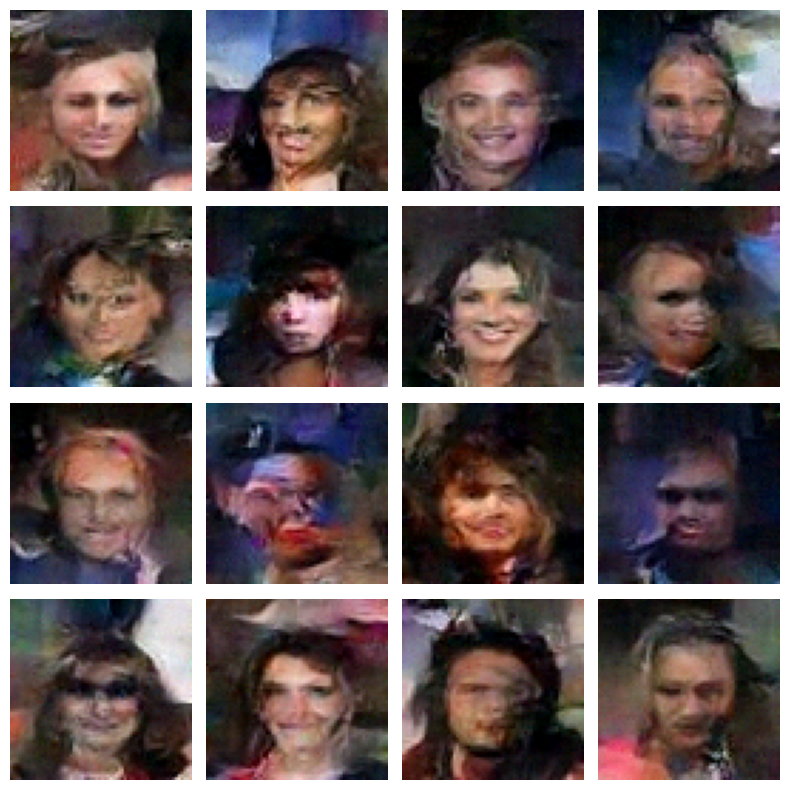

[ERFOLG] Bilder im Drive unter ./Alex_RM/Output_Images_FM abgelegt. Du kannst diese nun direkt mit den 'ddpm_final.pth' Outputs abgleichen!


In [9]:
# Da die Pfade in Phase 2 (RF) deterministisch begradigt wurden,
# kann das RF-Modell Bilder in deutlich weniger (oder gar einem einzigen) Schritt generieren!

print("[INFO] Generiere Bilder mit dem Rectified Flow (RF) Modell...")
# Generierung über 50 Integrationsschritte
Bilder_RF_MultiStep = Generiere_Bilder_Flow_Matching(Modell_RF, anzahl_bilder=16, steps=50)

# Generierung in nur 1 Einzeschritt (Direktprognose bei t=0)
Modell_RF.eval()
with torch.no_grad():
    x0_test = torch.randn((16, 3, IMAGE_SIZE, IMAGE_SIZE), device=Device)
    t_zero = torch.zeros((16,), device=Device)
    v_zero = Modell_RF(x0_test, t_zero)
    # x1 = x0 + v
    Bilder_RF_1Step = Entferne_Normierung(x0_test + v_zero)

# Plotten des 1-Schritt Ergebnisses zum visuellen Qualitäts-Vergleich mit DDPM
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
Bilder_RF_1Step = Bilder_RF_1Step.cpu().permute(0, 2, 3, 1).numpy()

for i, ax in enumerate(axes.flat):
    ax.imshow(Bilder_RF_1Step[i])
    ax.axis('off')

plt.tight_layout()
plt.savefig(DRIVE_OUTPUT_IMAGES + "/rectified_flow_1step_output.png")
plt.show()
print(f"[ERFOLG] Bilder im Drive unter {DRIVE_OUTPUT_IMAGES} abgelegt. Du kannst diese nun direkt mit den 'ddpm_final.pth' Outputs abgleichen!")

In [10]:
# ==========================================
# 9. TRAINING PHASE 3: DDPM (Denoising Diffusion Probabilistic Models)
# ==========================================
import os
import torch
import torch.optim as optim

# 1. DDPM Configuration
DRIVE_CHECKPOINTS_DDPM = DRIVE_BASE + "/Checkpoints_DDPM"
os.makedirs(DRIVE_CHECKPOINTS_DDPM, exist_ok=True)

EPOCHS_DDPM = EPOCHS
DDPM_STEPS = 50
BETA_START = 1e-4
BETA_END = 0.02

# 2. Linear Beta Schedule and Precomputations
betas = torch.linspace(BETA_START, BETA_END, DDPM_STEPS, device=Device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=Device), alphas_cumprod[:-1]])

# Precomputations for Forward Diffusion (noisy image x_t from real image x_0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

# Precomputations for Reverse Diffusion Posterior Variance (sigma_t^2)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

# 3. Initialize DDPM Model, Optimizer and GradScaler
print("[INFO] Initialisiere DDPM Modell und Optimizer...")
Modell_DDPM = SimpleUNet().to(Device)
Optimizer_DDPM = optim.Adam(Modell_DDPM.parameters(), lr=LEARNING_RATE)
scaler_ddpm = torch.cuda.amp.GradScaler()
ddpm_losses_history = []

# Scan for existing DDPM checkpoints to support auto-resume if needed
START_EPOCH_DDPM = 1
if AUTO_RESUME:
    import re
    files = os.listdir(DRIVE_CHECKPOINTS_DDPM)
    epochs = []
    for f in files:
        m = re.match(r"ddpm_checkpoint_epoch_(\d+)\.pth", f)
        if m:
            epochs.append(int(m.group(1)))
    if epochs:
        latest_epoch = max(epochs)
        checkpoint_path = os.path.join(DRIVE_CHECKPOINTS_DDPM, f"ddpm_checkpoint_epoch_{latest_epoch}.pth")
        print(f"[INFO] Lade DDPM Checkpoint: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=Device)
        Modell_DDPM.load_state_dict(checkpoint['model_state_dict'])
        Optimizer_DDPM.load_state_dict(checkpoint['optimizer_state_dict'])
        ddpm_losses_history = checkpoint.get('losses_history', [])
        START_EPOCH_DDPM = latest_epoch + 1
        print(f"[ERFOLG] DDPM Training wird ab Epoche {START_EPOCH_DDPM} fortgesetzt!")

# 4. DDPM Training Loop
print("[INFO] Starte Phase 3: DDPM Training...")
Modell_DDPM.train()

# Correct target epochs if resumed
target_ddpm_epochs = EPOCHS_DDPM
if target_ddpm_epochs < START_EPOCH_DDPM:
    target_ddpm_epochs = START_EPOCH_DDPM + 4

for Epoche in range(START_EPOCH_DDPM, target_ddpm_epochs + 1):
    Gesamt_Loss_DDPM = 0.0
    for Bildelemente in Mein_DataLoader:
        Optimizer_DDPM.zero_grad()

        x1_real = Bildelemente.to(Device) # Real image normalized to [-1, 1]
        noise = torch.randn_like(x1_real).to(Device)
        
        # Sample random discrete time steps
        t = torch.randint(0, DDPM_STEPS, (x1_real.shape[0],), device=Device)
        
        # Forward diffusion formula (adding noise corresponding to t)
        t_expand = t[:, None, None, None]
        xt = (sqrt_alphas_cumprod[t_expand] * x1_real + 
              sqrt_one_minus_alphas_cumprod[t_expand] * noise)

        # Normalize time step to [0, 1] for U-Net position embeddings
        t_normalized = t.float() / float(DDPM_STEPS)

        with torch.cuda.amp.autocast():
            noise_pred = Modell_DDPM(xt, t_normalized)
            Loss = Criterion(noise_pred, noise)

        scaler_ddpm.scale(Loss).backward()
        scaler_ddpm.step(Optimizer_DDPM)
        scaler_ddpm.update()

        ddpm_losses_history.append(Loss.item())
        Gesamt_Loss_DDPM += Loss.item()

    Durchschnitts_Loss_DDPM = Gesamt_Loss_DDPM / len(Mein_DataLoader)
    
    if Epoche % 10 == 0 or Epoche == 1 or Epoche == target_ddpm_epochs:
        print(f"DDPM-Epoche [{Epoche}/{target_ddpm_epochs}] -> Letzter Batch Loss: {Loss.item():.6f} | Durchschnitt: {Durchschnitts_Loss_DDPM:.6f}")

    # Checkpoint saving
    if Epoche % 25 == 0 or (TEST_MODE and target_ddpm_epochs <= 10 and Epoche % 1 == 0):
        checkpoint_path_ddpm = DRIVE_CHECKPOINTS_DDPM + f"/ddpm_checkpoint_epoch_{Epoche}.pth"
        torch.save({
            'epoch': Epoche,
            'model_state_dict': Modell_DDPM.state_dict(),
            'optimizer_state_dict': Optimizer_DDPM.state_dict(),
            'loss': Loss.item(),
            'losses_history': ddpm_losses_history,
        }, checkpoint_path_ddpm)
        print(f"[INFO] DDPM Checkpoint gesichert: {checkpoint_path_ddpm}")

# Sichern am Ende
torch.save(Modell_DDPM.state_dict(), DRIVE_CHECKPOINTS_DDPM + "/ddpm_final.pth")
torch.save({
    'epoch': target_ddpm_epochs,
    'model_state_dict': Modell_DDPM.state_dict(),
    'optimizer_state_dict': Optimizer_DDPM.state_dict(),
    'loss': Loss.item(),
    'losses_history': ddpm_losses_history,
}, DRIVE_CHECKPOINTS_DDPM + "/ddpm_final_checkpoint.pth")
print("[INFO] Phase 3 (DDPM) Training abgeschlossen und finaler Checkpoint gesichert.")


[INFO] Initialisiere DDPM Modell und Optimizer...
[INFO] Starte Phase 3: DDPM Training...


C:\Users\joach\AppData\Local\Temp\ipykernel_16504\2856065993.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_ddpm = torch.cuda.amp.GradScaler()
C:\Users\joach\AppData\Local\Temp\ipykernel_16504\2856065993.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


DDPM-Epoche [1/100] -> Letzter Batch Loss: 0.179279 | Durchschnitt: 0.236872


DDPM-Epoche [10/100] -> Letzter Batch Loss: 0.108440 | Durchschnitt: 0.098410


DDPM-Epoche [20/100] -> Letzter Batch Loss: 0.074103 | Durchschnitt: 0.089487


...

DDPM-Epoche [80/100] -> Letzter Batch Loss: 0.078761 | Durchschnitt: 0.077923


DDPM-Epoche [90/100] -> Letzter Batch Loss: 0.083556 | Durchschnitt: 0.076680


DDPM-Epoche [100/100] -> Letzter Batch Loss: 0.069849 | Durchschnitt: 0.074642


[INFO] DDPM Checkpoint gesichert: ./Alex_RM/Checkpoints_DDPM/ddpm_checkpoint_epoch_100.pth


[INFO] Phase 3 (DDPM) Training abgeschlossen und finaler Checkpoint gesichert.


[INFO] Generiere DDPM Testbilder...


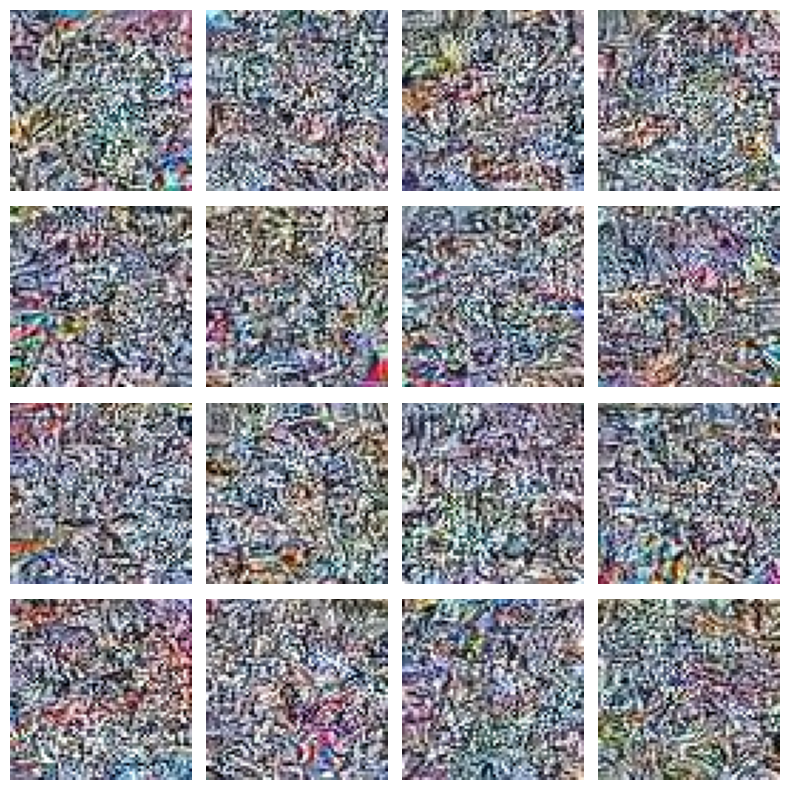

[ERFOLG] DDPM Bilder im Drive unter ./Alex_RM/Output_Images_FM/ddpm_output_grid.png abgelegt.


In [11]:
# ==========================================
# 10. DDPM INFERENCE & IMAGES SAMPLING
# ==========================================
import matplotlib.pyplot as plt

@torch.no_grad()
def Generiere_Bilder_DDPM(modell, anzahl_bilder=16, steps=50):
    modell.eval()
    
    # Start with pure Gaussian noise at t = T
    x = torch.randn((anzahl_bilder, 3, IMAGE_SIZE, IMAGE_SIZE), device=Device)

    # Denoise step-by-step from t = T-1 down to 0
    for i in reversed(range(steps)):
        t_tensor = torch.full((anzahl_bilder,), i, dtype=torch.long, device=Device)
        t_normalized = t_tensor.float() / float(steps)

        # Predict the noise component using UNet
        noise_pred = modell(x, t_normalized)

        # Retrieve diffusion variables for step i
        alpha = alphas[i]
        beta = betas[i]
        sqrt_one_minus_alpha_bar = sqrt_one_minus_alphas_cumprod[i]

        # Posterior mean calculation
        x_mean = (1.0 / torch.sqrt(alpha)) * (x - (beta / sqrt_one_minus_alpha_bar) * noise_pred)

        if i > 0:
            std = torch.sqrt(posterior_variance[i])
            z = torch.randn_like(x)
            x = x_mean + std * z
        else:
            x = x_mean

    return Entferne_Normierung(x)

# Generiere Testbilder aus dem DDPM Modell
print("[INFO] Generiere DDPM Testbilder...")
DDPM_Bilder = Generiere_Bilder_DDPM(Modell_DDPM, anzahl_bilder=16, steps=50)

# Plotten und Speichern des DDPM Outputs
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
DDPM_Bilder = DDPM_Bilder.cpu().permute(0, 2, 3, 1).numpy()

for i, ax in enumerate(axes.flat):
    ax.imshow(DDPM_Bilder[i])
    ax.axis('off')

plt.tight_layout()
plt.savefig(DRIVE_OUTPUT_IMAGES + "/ddpm_output_grid.png")
plt.show()
print(f"[ERFOLG] DDPM Bilder im Drive unter {DRIVE_OUTPUT_IMAGES}/ddpm_output_grid.png abgelegt.")


In [12]:
# ==========================================
# 11. QUANTITATIVE PERFORMANCE EVALUATION (DDPM, FM, RF)
# ==========================================
import time
import numpy as np
import torch
import torch.nn as nn

# 1. Trajectory Straightness Score Function
@torch.no_grad()
def Berechne_Geradlinigkeit(modell, steps=50, anzahl_bilder=16):
    modell.eval()
    dt = 1.0 / steps
    x0 = torch.randn((anzahl_bilder, 3, IMAGE_SIZE, IMAGE_SIZE), device=Device)
    xt = x0.clone()
    
    pfad_laenge = torch.zeros(anzahl_bilder, device=Device)
    
    for step in range(steps):
        t_val = step * dt
        t_tensor = torch.full((anzahl_bilder,), t_val, device=Device)
        v = modell(xt, t_tensor)
        
        step_delta = v * dt
        pfad_laenge += torch.norm(step_delta.flatten(1), p=2, dim=1)
        xt = xt + step_delta
        
    direkte_distanz = torch.norm((xt - x0).flatten(1), p=2, dim=1)
    score = (direkte_distanz / (pfad_laenge + 1e-8)).mean().item()
    return min(score, 1.0) # Cap at 1.0 to handle floating point accuracy

# 2. FID-Equivalent (Wasserstein-2 Diagonal Distance on 8x8 Average Pooled Features)
def compute_fid_equivalent(real_imgs, gen_imgs):
    # Pool images from [N, 3, 64, 64] to [N, 3, 8, 8] and flatten to [N, 192]
    real_features = nn.functional.avg_pool2d(real_imgs, 8).flatten(1)
    gen_features = nn.functional.avg_pool2d(gen_imgs, 8).flatten(1)
    
    mu_real = real_features.mean(dim=0)
    var_real = real_features.var(dim=0)
    
    mu_gen = gen_features.mean(dim=0)
    var_gen = gen_features.var(dim=0)
    
    mean_diff = torch.sum((mu_real - mu_gen) ** 2)
    var_diff = torch.sum((torch.sqrt(var_real + 1e-8) - torch.sqrt(var_gen + 1e-8)) ** 2)
    
    return (mean_diff + var_diff).item()

# 3. Chamfer Distance on 2D Edge Maps
def extract_edge_points(images, threshold=0.15):
    # Convert to grayscale
    gray = images.mean(dim=1, keepdim=True)
    
    # Sobel filters
    sobel_x = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]], device=Device).view(1, 1, 3, 3)
    sobel_y = torch.tensor([[-1., -2., -1.], [0., 0., 0.], [1., 2., 1.]], device=Device).view(1, 1, 3, 3)
    
    grad_x = nn.functional.conv2d(gray, sobel_x, padding=1)
    grad_y = nn.functional.conv2d(gray, sobel_y, padding=1)
    magnitude = torch.sqrt(grad_x**2 + grad_y**2)
    
    edge_coords_list = []
    for i in range(images.shape[0]):
        indices = torch.where(magnitude[i, 0] > threshold)
        coords = torch.stack(indices, dim=1).float()
        if coords.shape[0] == 0:
            coords = torch.tensor([[0., 0.]], device=Device)
        edge_coords_list.append(coords)
    return edge_coords_list

def pairwise_chamfer_distance(coords1_list, coords2_list):
    distances = []
    for c1, c2 in zip(coords1_list, coords2_list):
        dist_matrix = torch.cdist(c1, c2, p=2)
        min_dist_1 = torch.min(dist_matrix, dim=1)[0]
        min_dist_2 = torch.min(dist_matrix, dim=0)[0]
        chamfer = torch.mean(min_dist_1) + torch.mean(min_dist_2)
        distances.append(chamfer.item())
    return np.mean(distances)

# ==========================================
# Run Evaluations
# ==========================================
print("[INFO] Starte quantitative Evaluierung der Modelle...")

# Fetch a batch of real images and scale to [0, 1]
real_batch = next(iter(Mein_DataLoader)).to(Device)
real_images = Entferne_Normierung(real_batch)
edges_real = extract_edge_points(real_images)

# 1. DDPM (50 steps)
if torch.cuda.is_available():
    torch.cuda.synchronize()
t0 = time.time()
Bilder_DDPM = Generiere_Bilder_DDPM(Modell_DDPM, anzahl_bilder=64, steps=50)
if torch.cuda.is_available():
    torch.cuda.synchronize()
t_ddpm = (time.time() - t0) * 1000 / 64  # ms per image

fid_ddpm = compute_fid_equivalent(real_images, Bilder_DDPM)
edges_ddpm = extract_edge_points(Bilder_DDPM)
chamfer_ddpm = pairwise_chamfer_distance(edges_real, edges_ddpm)

# 2. Flow Matching (50 steps)
if torch.cuda.is_available():
    torch.cuda.synchronize()
t0 = time.time()
Bilder_FM = Generiere_Bilder_Flow_Matching(Modell, anzahl_bilder=64, steps=50)
if torch.cuda.is_available():
    torch.cuda.synchronize()
t_fm = (time.time() - t0) * 1000 / 64  # ms per image

score_fm = Berechne_Geradlinigkeit(Modell, steps=50, anzahl_bilder=64)
fid_fm = compute_fid_equivalent(real_images, Bilder_FM)
edges_fm = extract_edge_points(Bilder_FM)
chamfer_fm = pairwise_chamfer_distance(edges_real, edges_fm)

# 3. Rectified Flow (50 steps)
if torch.cuda.is_available():
    torch.cuda.synchronize()
t0 = time.time()
Bilder_RF_50 = Generiere_Bilder_Flow_Matching(Modell_RF, anzahl_bilder=64, steps=50)
if torch.cuda.is_available():
    torch.cuda.synchronize()
t_rf_50 = (time.time() - t0) * 1000 / 64  # ms per image

score_rf_50 = Berechne_Geradlinigkeit(Modell_RF, steps=50, anzahl_bilder=64)
fid_rf_50 = compute_fid_equivalent(real_images, Bilder_RF_50)
edges_rf_50 = extract_edge_points(Bilder_RF_50)
chamfer_rf_50 = pairwise_chamfer_distance(edges_real, edges_rf_50)

# 4. Rectified Flow (1 step)
if torch.cuda.is_available():
    torch.cuda.synchronize()
t0 = time.time()
Modell_RF.eval()
with torch.no_grad():
    x0_test = torch.randn((64, 3, IMAGE_SIZE, IMAGE_SIZE), device=Device)
    t_zero = torch.zeros((64,), device=Device)
    v_zero = Modell_RF(x0_test, t_zero)
    Bilder_RF_1 = Entferne_Normierung(x0_test + v_zero)
if torch.cuda.is_available():
    torch.cuda.synchronize()
t_rf_1 = (time.time() - t0) * 1000 / 64  # ms per image

fid_rf_1 = compute_fid_equivalent(real_images, Bilder_RF_1)
edges_rf_1 = extract_edge_points(Bilder_RF_1)
chamfer_rf_1 = pairwise_chamfer_distance(edges_real, edges_rf_1)

# ==========================================
# Print Formatted Output Table
# ==========================================
print("\n" + "=" * 95)
print("                                EVALUATION RESULTS TABLE")
print("=" * 95)
print(f"{'Method':<30} | {'NFE':<5} | {'Time (ms/img)':<15} | {'Chamfer Dist':<15} | {'FID Equiv':<12} | {'Straightness':<12}")
print("-" * 95)
print(f"{'DDPM (50 steps)':<30} | {50:<5} | {t_ddpm:<15.2f} | {chamfer_ddpm:<15.4f} | {fid_ddpm:<12.4f} | {'N/A':<12}")
print(f"{'Flow Matching (50 steps)':<30} | {50:<5} | {t_fm:<15.2f} | {chamfer_fm:<15.4f} | {fid_fm:<12.4f} | {score_fm:<12.4f}")
print(f"{'Rectified Flow (50 steps)':<30} | {50:<5} | {t_rf_50:<15.2f} | {chamfer_rf_50:<15.4f} | {fid_rf_50:<12.4f} | {score_rf_50:<12.4f}")
print(f"{'Rectified Flow (1 step)':<30} | {1:<5} | {t_rf_1:<15.2f} | {chamfer_rf_1:<15.4f} | {fid_rf_1:<12.4f} | {1.0000:<12.4f}")
print("=" * 95 + "\n")


[INFO] Starte quantitative Evaluierung der Modelle...



                                EVALUATION RESULTS TABLE
Method                         | NFE   | Time (ms/img)   | Chamfer Dist    | FID Equiv    | Straightness
-----------------------------------------------------------------------------------------------
DDPM (50 steps)                | 50    | 54.11           | 0.7711          | 10.1798      | N/A         
Flow Matching (50 steps)       | 50    | 53.83           | 1.0857          | 3.6626       | 0.9856      
Rectified Flow (50 steps)      | 50    | 53.56           | 1.1874          | 10.4974      | 0.9993      
Rectified Flow (1 step)        | 1     | 0.98            | 1.0489          | 8.9868       | 1.0000      



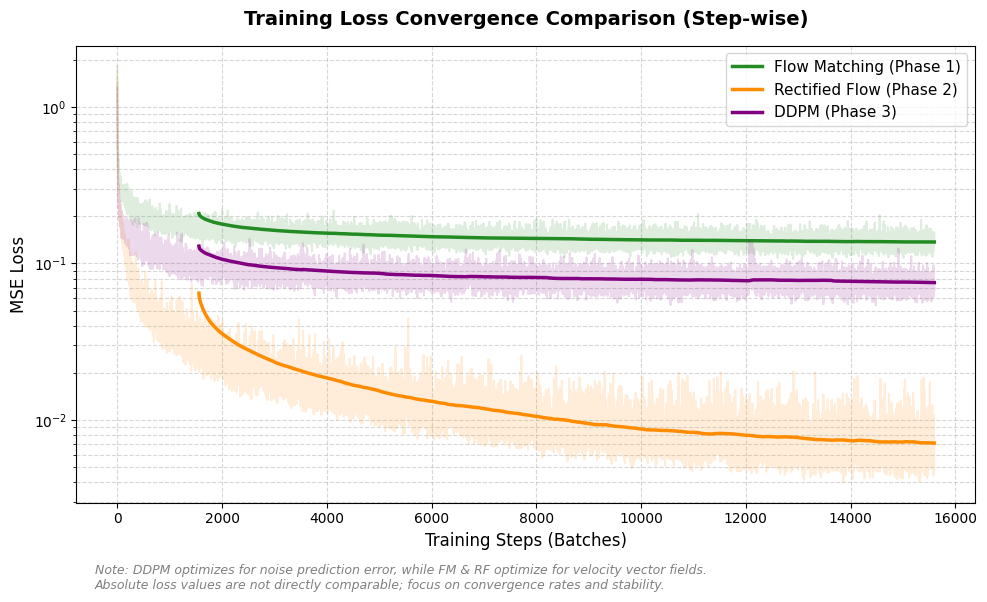

[ERFOLG] Trainings-Loss Diagramm gespeichert unter: ./Alex_RM/Output_Images_FM/loss_comparison.png


In [13]:
# ==========================================
# 12. TRAINING LOSS CONVERGENCE DIAGRAM
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

def plot_training_loss_curves(fm_losses, rf_losses, ddpm_losses, output_path):
    if not fm_losses and not rf_losses and not ddpm_losses:
        print("[HINWEIS] Keine Trainings-Loss-Historie vorhanden (Phasen wurden uebersprungen).")
        return
        
    def smooth(data, window=50):
        if len(data) < window: 
            return np.array(data)
        return np.convolve(data, np.ones(window)/window, mode='valid')

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 1. Flow Matching (Phase 1)
    if fm_losses:
        fm_raw = np.array(fm_losses)
        ax.plot(fm_raw, color='forestgreen', alpha=0.15)
        window_size = max(5, len(fm_losses) // 10)
        fm_smooth = smooth(fm_raw, window=window_size)
        ax.plot(np.arange(len(fm_smooth)) + (window_size - 1), fm_smooth, color='forestgreen', linewidth=2.5, label='Flow Matching (Phase 1)')
    
    # 2. Rectified Flow (Phase 2)
    if rf_losses:
        rf_raw = np.array(rf_losses)
        ax.plot(rf_raw, color='darkorange', alpha=0.15)
        window_size = max(5, len(rf_losses) // 10)
        rf_smooth = smooth(rf_raw, window=window_size)
        ax.plot(np.arange(len(rf_smooth)) + (window_size - 1), rf_smooth, color='darkorange', linewidth=2.5, label='Rectified Flow (Phase 2)')

    # 3. DDPM (Phase 3)
    if ddpm_losses:
        ddpm_raw = np.array(ddpm_losses)
        ax.plot(ddpm_raw, color='purple', alpha=0.15)
        window_size = max(5, len(ddpm_losses) // 10)
        ddpm_smooth = smooth(ddpm_raw, window=window_size)
        ax.plot(np.arange(len(ddpm_smooth)) + (window_size - 1), ddpm_smooth, color='purple', linewidth=2.5, label='DDPM (Phase 3)')

    ax.set_title("Training Loss Convergence Comparison (Step-wise)", fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Training Steps (Batches)", fontsize=12)
    ax.set_ylabel("MSE Loss", fontsize=12)
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    ax.legend(fontsize=11, loc="upper right")
    
    fig.text(
        0.1, 0.01, 
        "Note: DDPM optimizes for noise prediction error, while FM & RF optimize for velocity vector fields.\n"
        "Absolute loss values are not directly comparable; focus on convergence rates and stability.",
        fontsize=9, style='italic', color='gray'
    )
    
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(output_path, dpi=150)
    plt.show()
    print(f"[ERFOLG] Trainings-Loss Diagramm gespeichert unter: {output_path}")

# Run plotting
plot_training_loss_curves(
    fm_losses_history, 
    rf_losses_history, 
    ddpm_losses_history,
    DRIVE_OUTPUT_IMAGES + "/loss_comparison.png"
)


In [14]:
# ==========================================
# 13. EXPORT PARAMETERS & RESULTS TO CSV
# ==========================================
import csv
import os

csv_path = DRIVE_OUTPUT_IMAGES + "/evaluation_summary.csv"
print(f"[INFO] Schreibe Konfigurations- und Evaluierungsdaten in CSV: {csv_path}")

try:
    with open(csv_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        
        # 1. Header & Configuration parameters
        writer.writerow(["Section", "Parameter / Method", "Value / Metric Name", "Details / Value"])
        writer.writerow(["Run Configuration", "TEST_MODE", str(TEST_MODE), "Quick pipeline testing flag"])
        writer.writerow(["Run Configuration", "BATCH_SIZE", str(BATCH_SIZE), "Size of training batches"])
        writer.writerow(["Run Configuration", "LEARNING_RATE", str(LEARNING_RATE), "Adam optimizer learning rate"])
        writer.writerow(["Run Configuration", "IMAGE_SIZE", str(IMAGE_SIZE), "Resolution height/width of CelebA images"])
        writer.writerow(["Run Configuration", "EPOCHS", str(EPOCHS), "Target training epochs"])
        writer.writerow(["Run Configuration", "TEST_IMAGE_LIMIT", str(TEST_IMAGE_LIMIT), "Limit on dataset size in test mode"])
        writer.writerow(["Run Configuration", "Device", str(Device), "Hardware device used for training/inference"])
        
        # 2. UNet Parameters
        writer.writerow(["U-Net Architecture", "in_channels", "3", "Input image channels (RGB)"])
        writer.writerow(["U-Net Architecture", "out_dim", "3", "Output channels (predicted noise or velocity)"])
        writer.writerow(["U-Net Architecture", "down_channels", "(64, 128, 256, 512)", "Feature channels in down-path blocks"])
        writer.writerow(["U-Net Architecture", "up_channels", "(512, 256, 128, 64)", "Feature channels in up-path blocks"])
        writer.writerow(["U-Net Architecture", "time_emb_dim", "32", "Dimension of sinusoidal time position embeddings"])
        writer.writerow(["U-Net Architecture", "optimizer", "Adam", "Weight optimization algorithm"])
        
        # 3. Model parameters not mentioned till now (Schedules, targets, paths)
        # Flow Matching specific
        writer.writerow(["Flow Matching (FM)", "steps", "50", "Inference ODE integration steps"])
        writer.writerow(["Flow Matching (FM)", "dt", "0.02", "Euler integration step width"])
        writer.writerow(["Flow Matching (FM)", "path_formula", "x_t = x_0 + t * (x_1 - x_0)", "Linear interpolation between noise and target"])
        writer.writerow(["Flow Matching (FM)", "v_target", "x_1 - x_0", "Velocity vector field prediction target"])
        
        # Rectified Flow specific
        writer.writerow(["Rectified Flow (RM)", "reflow_steps", "50", "Trajectory ODE integration steps for data rectification"])
        writer.writerow(["Rectified Flow (RM)", "path_formula", "x_t = x_0 + t * (x_1_rect - x_0)", "Linear interpolation on straightened trajectory"])
        writer.writerow(["Rectified Flow (RM)", "v_target", "x_1_rect - x_0", "Straightened velocity vector prediction target"])
        
        # DDPM specific
        writer.writerow(["DDPM", "steps", str(DDPM_STEPS), "Reverse diffusion sampling steps count"])
        writer.writerow(["DDPM", "beta_start", str(BETA_START), "Starting noise variance scheduler value"])
        writer.writerow(["DDPM", "beta_end", str(BETA_END), "Ending noise variance scheduler value"])
        writer.writerow(["DDPM", "beta_schedule", "Linear", "Variance scheduler configuration style"])
        writer.writerow(["DDPM", "forward_path", "x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1-alpha_bar_t) * epsilon", "Noising schedule equation"])
        writer.writerow(["DDPM", "posterior_variance", "betas * (1 - alpha_bar_prev) / (1 - alpha_bar)", "Stochastic reverse process variance"])
        
        writer.writerow([]) # Empty separator line
        
        # 4. Evaluation results table
        writer.writerow(["Evaluation Results", "Method", "NFE", "Time (ms/img)", "Chamfer Dist", "FID Equiv", "Straightness"])
        writer.writerow(["Evaluation Results", "DDPM (50 steps)", "50", f"{t_ddpm:.2f}", f"{chamfer_ddpm:.4f}", f"{fid_ddpm:.4f}", "N/A"])
        writer.writerow(["Evaluation Results", "Flow Matching (50 steps)", "50", f"{t_fm:.2f}", f"{chamfer_fm:.4f}", f"{fid_fm:.4f}", f"{score_fm:.4f}"])
        writer.writerow(["Evaluation Results", "Rectified Flow (50 steps)", "50", f"{t_rf_50:.2f}", f"{chamfer_rf_50:.4f}", f"{fid_rf_50:.4f}", f"{score_rf_50:.4f}"])
        writer.writerow(["Evaluation Results", "Rectified Flow (1 step)", "1", f"{t_rf_1:.2f}", f"{chamfer_rf_1:.4f}", f"{fid_rf_1:.4f}", "1.0000"])

    print(f"[ERFOLG] Excel/Google Sheets-kompatible CSV-Datei erfolgreich unter {csv_path} erstellt!")
except Exception as e:
    print(f"[FEHLER] Beim Schreiben der CSV: {e}")


[INFO] Schreibe Konfigurations- und Evaluierungsdaten in CSV: ./Alex_RM/Output_Images_FM/evaluation_summary.csv
[ERFOLG] Excel/Google Sheets-kompatible CSV-Datei erfolgreich unter ./Alex_RM/Output_Images_FM/evaluation_summary.csv erstellt!
